# PyGIMLi karst reference model and survey-geometry optimisation

This notebook builds a fine-mesh **reference model** for a water-filled cave/void,
then uses the full synthetic travel-time table to test survey-design choices.

Core idea:

1. Build one oversampled reference survey.
2. Forward model **without cave** and **with cave** using the same survey.
3. Save the full travel-time table.
4. Quantify cave detectability from travel-time residuals.
5. Decimate shots and receivers without recomputing the forward model.
6. Test whether sparse designs preserve cave detectability.
7. Optionally invert selected subsets.

Reference geometry:

- Cave centre at `x = 0 m`
- Geophones from `-75` to `+75 m` at `1 m` spacing: **151 receivers**
- Shots from `-100` to `+100 m` at `1 m` spacing: **201 shots**
- Maximum source-receiver offset: **175 m**

Important modelling philosophy:

- The full 1 m survey is the numerical/synthetic reference.
- SmartSolo-style 4 m spacing can be emulated by subsetting receivers.
- Fewer shots and shorter apertures can be emulated by subsetting shots.
- Recompute forward models only when changing the earth model, cave model, mesh, or physics.

## Scientific questions

This notebook is meant to answer:

1. **Can the cave be detected in first-arrival travel times?**
2. **Which ray paths are most sensitive to the cave?**
3. **How much do we lose if we remove shots?**
4. **How much do we lose if we remove geophones?**
5. **How much aperture do we need?**
6. **Does a dense geophone line outperform a sparse nodal line?**
7. **Should we estimate the background 2-layer model first, away from the cave, before looking for cave anomalies?**

The answer to the last question is probably **yes**. A good workflow is:

- First estimate or constrain the 1-D/2-layer background using shots and receivers away from the suspected cave zone.
- Then look for structured residuals around the suspected cave.
- Finally invert selected datasets for 2-D velocity anomalies and compare how well the cave is imaged.

In [1]:
from pathlib import Path
import copy
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pygimli as pg
    import pygimli.meshtools as mt
    import pygimli.physics.traveltime as tt
except ImportError as exc:
    raise ImportError(
        "PyGIMLi is not installed in this environment. Try:\n\n"
        "mamba create -n pg -c conda-forge pygimli jupyterlab pandas matplotlib pyyaml\n"
        "conda activate pg\n"
    ) from exc

pg.utils.units.quants["vel"]["cMap"] = "inferno_r"

## 1. Load the reference YAML

In [2]:
CONFIG_FILE = Path("karst_reference_oversampled_survey.yml")

if not CONFIG_FILE.exists():
    CONFIG_FILE = Path("/mnt/data/karst_reference_oversampled_survey.yml")

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Could not find karst_reference_oversampled_survey.yml. "
        "Place it in the notebook directory or /mnt/data."
    )

with CONFIG_FILE.open("r") as f:
    cfg = yaml.safe_load(f)

OUTPUT_DIR = Path(cfg.get("output", {}).get("dir", "karst_reference_model_output")) / "pygimli_reference_model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loaded: {CONFIG_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
cfg.keys()

Loaded: karst_reference_oversampled_survey.yml
Output directory: karst_reference_oversampled_output/pygimli_reference_model


dict_keys(['compute', 'output', 'domain', 'deepwave', 'survey', 'earth_model', 'cave', 'coordinate_convention', 'pygimli'])

## 2. PyGIMLi reference settings

In [3]:
pygimli_defaults = {
    "mesh_quality": 34.0,
    "mesh_area_m2": 0.50,
    "cave_mesh_area_m2": 0.025,
    "cave_buffer_m": 10.0,
    "cave_buffer_mesh_area_m2": 0.05,
    "noise_level_relative": 0.001,
    "noise_abs_s": 0.0005,
    "error_relative": 0.03,
    "error_abs_s": 0.001,
    "seed": 20260424,
    "use_cabled_receivers": True,
    "use_smartsolo_receivers": False,
    "use_extra_shots": False,
    "use_node_shots": False,
    "use_regular_shots": True,
    "inversion": {
        "run": False,
        "sec_nodes": 2,
        "para_max_cell_size_m2": 5.0,
        "max_iter": 8,
        "lam": 20.0,
    },
    "decimation_experiments": {
        "receiver_spacings_m": [1, 2, 3, 4, 5, 10],
        "shot_spacings_m": [1, 2, 4, 5, 10],
        "receiver_halfwidths_m": [25, 35, 50, 75],
        "shot_halfwidths_m": [40, 60, 80, 100],
    }
}

pgcfg = copy.deepcopy(pygimli_defaults)
pgcfg.update(cfg.get("pygimli", {}))
pgcfg["inversion"].update(cfg.get("pygimli", {}).get("inversion", {}))
pgcfg["decimation_experiments"].update(cfg.get("pygimli", {}).get("decimation_experiments", {}))

# Force reference mesh to be at least this fine.
pgcfg["mesh_area_m2"] = min(float(pgcfg.get("mesh_area_m2", 0.50)), 0.50)
pgcfg["cave_mesh_area_m2"] = min(float(pgcfg.get("cave_mesh_area_m2", 0.025)), 0.025)
pgcfg["cave_buffer_mesh_area_m2"] = min(float(pgcfg.get("cave_buffer_mesh_area_m2", 0.05)), 0.05)
pgcfg["cave_buffer_m"] = max(float(pgcfg.get("cave_buffer_m", 10.0)), 10.0)
pgcfg["inversion"]["run"] = False

pgcfg

{'mesh_quality': 34.0,
 'mesh_area_m2': 0.5,
 'cave_mesh_area_m2': 0.025,
 'cave_buffer_m': 10.0,
 'cave_buffer_mesh_area_m2': 0.05,
 'noise_level_relative': 0.001,
 'noise_abs_s': 0.0005,
 'error_relative': 0.03,
 'error_abs_s': 0.001,
 'seed': 20260424,
 'use_cabled_receivers': True,
 'use_smartsolo_receivers': False,
 'use_extra_shots': False,
 'use_node_shots': False,
 'use_regular_shots': True,
 'inversion': {'run': False,
  'sec_nodes': 2,
  'para_max_cell_size_m2': 10.0,
  'max_iter': 8,
  'lam': 20.0},
 'decimation_experiments': {'receiver_spacings_m': [1, 2, 3, 4, 5, 10],
  'shot_spacings_m': [1, 2, 4, 5, 10],
  'receiver_halfwidths_m': [25, 35, 50, 75],
  'shot_halfwidths_m': [40, 60, 80, 100],
  'description': 'Generate the full 1 m shot/receiver travel-time table first, then subset by shot spacing, receiver spacing, and aperture for survey-design tests.'}}

## 3. Shared geometry and material helpers

In [4]:
def depth_to_y(depth_m):
    return -float(depth_m)

def y_to_depth(y_m):
    return -float(y_m)

def layer_at_depth(depth_m, cfg):
    for layer in cfg["earth_model"]["layers"]:
        if layer["z_min_m"] <= depth_m <= layer["z_max_m"]:
            return layer
    bg = cfg["earth_model"]["background"]
    return {
        "name": "background",
        "z_min_m": cfg["domain"]["z_min_m"],
        "z_max_m": cfg["domain"]["z_max_m"],
        "vp_m_s": bg["vp_m_s"],
        "vs_m_s": bg.get("vs_m_s", np.nan),
        "density_kg_m3": bg["density_kg_m3"],
        "qkappa": bg.get("qkappa", np.nan),
        "qmu": bg.get("qmu", np.nan),
    }

def get_gradient_value(cfg, prop_name, depth_m, layer):
    base = float(layer[prop_name])
    grad_cfg = cfg["earth_model"].get("gradient", {})
    if not bool(grad_cfg.get("enabled", False)):
        return base
    gradient_key = {
        "vp_m_s": "vp_gradient_per_m",
        "vs_m_s": "vs_gradient_per_m",
        "density_kg_m3": "density_gradient_per_m",
    }[prop_name]
    grad = float(layer.get(gradient_key, grad_cfg.get(gradient_key, 0.0)))
    return base + grad * (float(depth_m) - float(layer["z_min_m"]))

def material_properties_at_depth(cfg, depth_m):
    layer = layer_at_depth(depth_m, cfg)
    return {
        "name": layer.get("name", "unknown"),
        "vp": get_gradient_value(cfg, "vp_m_s", depth_m, layer),
        "vs": get_gradient_value(cfg, "vs_m_s", depth_m, layer) if "vs_m_s" in layer else np.nan,
        "rho": get_gradient_value(cfg, "density_kg_m3", depth_m, layer),
        "qkappa": layer.get("qkappa", np.nan),
        "qmu": layer.get("qmu", np.nan),
    }

def cave_material(cfg):
    water = cfg["cave"].get("water", {})
    return {
        "vp": float(water.get("vp_m_s", 1500.0)),
        "vs": float(water.get("vs_m_s", 0.0)),
        "rho": float(water.get("density_kg_m3", 1000.0)),
        "qkappa": float(water.get("qkappa", np.nan)),
        "qmu": float(water.get("qmu", np.nan)),
    }

## 4. Build the oversampled reference survey

In [5]:
def cabled_receiver_positions(cfg):
    cabled = cfg["survey"].get("cabled", {})
    if not cabled.get("enabled", False):
        raise ValueError("Reference model expects survey.cabled.enabled = true")
    z = float(cabled.get("receiver_depth_m", 0.0))
    start = float(cabled["start_m"])
    spacing = float(cabled["spacing_m"])
    n = int(cabled["n_channels"])
    rows = []
    for chan in range(n):
        x = start + chan * spacing
        rows.append({"kind": "receiver", "array": "cabled", "channel": chan + 1,
                     "x_m": x, "z_m": z, "y_m": -z, "label": f"G{chan+1:03d}"})
    df = pd.DataFrame(rows)
    df["receiver_id"] = np.arange(len(df))
    return df

def shot_positions(cfg):
    shots_cfg = cfg["survey"]["shots"]
    z = float(shots_cfg.get("source_depth_m", 0.0))
    xs = np.arange(float(shots_cfg["regular_start_m"]),
                   float(shots_cfg["regular_end_m"]) + 0.5 * float(shots_cfg["regular_spacing_m"]),
                   float(shots_cfg["regular_spacing_m"]))
    rows = []
    for i, x in enumerate(xs, start=1):
        rows.append({"kind": "shot", "source_type": "regular", "x_m": float(x),
                     "z_m": z, "y_m": -z, "label": f"S{i:03d}"})
    df = pd.DataFrame(rows)
    df["shot_id"] = np.arange(len(df))
    return df

receivers = cabled_receiver_positions(cfg)
shots = shot_positions(cfg)
print(f"Reference receivers: {len(receivers)}")
print(f"Reference shots: {len(shots)}")
print(f"Nominal shot-receiver pairs: {len(receivers) * len(shots)}")
print(f"Receiver x-range: {receivers['x_m'].min()} to {receivers['x_m'].max()} m")
print(f"Shot x-range: {shots['x_m'].min()} to {shots['x_m'].max()} m")
display(receivers.head())
display(shots.head())

Reference receivers: 151
Reference shots: 201
Nominal shot-receiver pairs: 30351
Receiver x-range: -75.0 to 75.0 m
Shot x-range: -100.0 to 100.0 m


,kind,array,channel,x_m,z_m,y_m,label,receiver_id
0,receiver,cabled,1,-75.0,1.0,-1.0,G001,0
1,receiver,cabled,2,-74.0,1.0,-1.0,G002,1
2,receiver,cabled,3,-73.0,1.0,-1.0,G003,2
3,receiver,cabled,4,-72.0,1.0,-1.0,G004,3
4,receiver,cabled,5,-71.0,1.0,-1.0,G005,4


,kind,source_type,x_m,z_m,y_m,label,shot_id
0,shot,regular,-100.0,1.0,-1.0,S001,0
1,shot,regular,-99.0,1.0,-1.0,S002,1
2,shot,regular,-98.0,1.0,-1.0,S003,2
3,shot,regular,-97.0,1.0,-1.0,S004,3
4,shot,regular,-96.0,1.0,-1.0,S005,4


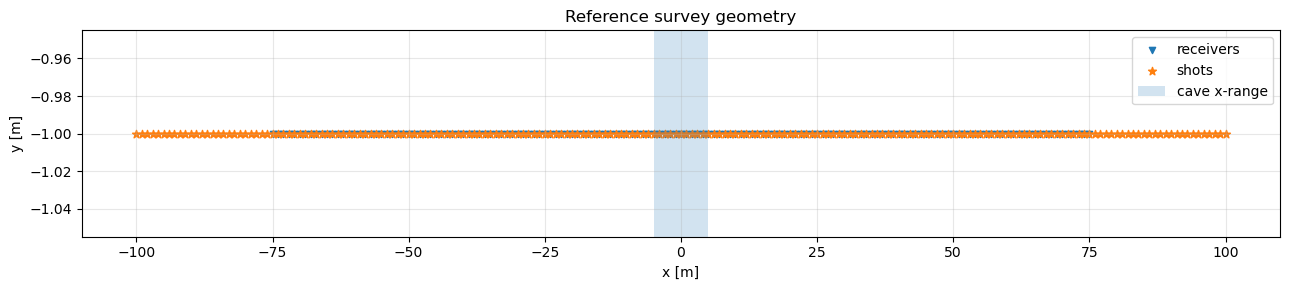

In [6]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.scatter(receivers["x_m"], receivers["y_m"], marker="v", s=20, label="receivers")
ax.scatter(shots["x_m"], shots["y_m"], marker="*", s=35, label="shots")
cave = cfg["cave"]
ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.2, label="cave x-range")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Reference survey geometry")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 5. Create the PyGIMLi travel-time scheme

In [7]:
def make_explicit_tt_scheme(shots, receivers):
    data = pg.DataContainer()
    data.registerSensorIndex("s")
    data.registerSensorIndex("g")
    sensor_lookup = {}
    def add_sensor(x, y):
        key = (round(float(x), 6), round(float(y), 6))
        if key not in sensor_lookup:
            sensor_lookup[key] = data.createSensor([float(x), float(y), 0.0])
        return int(sensor_lookup[key])
    shot_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in shots.iterrows()]
    receiver_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in receivers.iterrows()]
    S, G = [], []
    for sid in shot_sensor_ids:
        for gid in receiver_sensor_ids:
            if sid != gid:
                S.append(sid); G.append(gid)
    data.resize(len(S))
    data.set("s", S); data.set("g", G); data.set("valid", np.ones(len(S)))
    return data

scheme = make_explicit_tt_scheme(shots, receivers)
print(f"Reference scheme: {scheme.sensorCount()} unique sensors")
print(f"Travel-time pairs: {scheme.size()}")

Reference scheme: 201 unique sensors
Travel-time pairs: 30200


## 6. Build the fine reference mesh

In [8]:
def make_layer_geometry(cfg, pgcfg):
    x0 = float(cfg["domain"]["x_min_m"]); x1 = float(cfg["domain"]["x_max_m"])
    geom = None
    for marker, layer in enumerate(cfg["earth_model"]["layers"], start=1):
        top = depth_to_y(layer["z_min_m"]); bottom = depth_to_y(layer["z_max_m"])
        poly = mt.createPolygon([[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
                                isClosed=True, marker=marker, area=pgcfg["mesh_area_m2"])
        geom = poly if geom is None else geom + poly
    return geom

def make_cave_buffer_geometry(cfg, pgcfg, marker):
    cave = cfg["cave"]; buffer_m = float(pgcfg.get("cave_buffer_m", 0.0))
    if buffer_m <= 0: return None
    x0 = float(cave["x_min_m"]) - buffer_m; x1 = float(cave["x_max_m"]) + buffer_m
    z0 = max(float(cfg["domain"]["z_min_m"]), float(cave["z_min_m"]) - buffer_m)
    z1 = min(float(cfg["domain"]["z_max_m"]), float(cave["z_max_m"]) + buffer_m)
    return mt.createPolygon([[x0, depth_to_y(z0)], [x1, depth_to_y(z0)],
                             [x1, depth_to_y(z1)], [x0, depth_to_y(z1)]],
                            isClosed=True, marker=marker, area=pgcfg["cave_buffer_mesh_area_m2"])

def make_cave_geometry(cfg, pgcfg, marker):
    cave = cfg["cave"]; geometry = cave.get("geometry", "rectangle").lower()
    if geometry == "rectangle":
        x0 = float(cave["x_min_m"]); x1 = float(cave["x_max_m"])
        top = depth_to_y(cave["z_min_m"]); bottom = depth_to_y(cave["z_max_m"])
        return mt.createPolygon([[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
                                isClosed=True, marker=marker, area=pgcfg["cave_mesh_area_m2"])
    if geometry in ("circle", "ellipse"):
        cx = float(cave.get("center_x_m", 0.5 * (cave["x_min_m"] + cave["x_max_m"])))
        cz = float(cave.get("center_z_m", 0.5 * (cave["z_min_m"] + cave["z_max_m"])))
        rx = float(cave.get("radius_x_m", 0.5 * (cave["x_max_m"] - cave["x_min_m"])))
        rz = float(cave.get("radius_z_m", 0.5 * (cave["z_max_m"] - cave["z_min_m"])))
        theta = np.linspace(0, 2*np.pi, int(cave.get("n_segments", 64)), endpoint=False)
        pts = np.column_stack([cx + rx*np.cos(theta), depth_to_y(cz) + rz*np.sin(theta)])
        return mt.createPolygon(pts.tolist(), isClosed=True, marker=marker, area=pgcfg["cave_mesh_area_m2"])
    raise ValueError(f"Unsupported cave geometry: {geometry}")

def make_pygimli_geometry(cfg, pgcfg, scheme, with_cave=True):
    geom = make_layer_geometry(cfg, pgcfg)
    cave_marker = len(cfg["earth_model"]["layers"]) + 1
    buffer_marker = cave_marker + 1
    buffer_geom = make_cave_buffer_geometry(cfg, pgcfg, marker=buffer_marker)
    if buffer_geom is not None: geom += buffer_geom
    if with_cave: geom += make_cave_geometry(cfg, pgcfg, marker=cave_marker)
    for pos in scheme.sensors(): geom.createNode([pos.x(), pos.y()])
    return geom, cave_marker, buffer_marker

def make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True):
    geom, cave_marker, buffer_marker = make_pygimli_geometry(cfg, pgcfg, scheme, with_cave=with_cave)
    mesh = mt.createMesh(geom, quality=pgcfg["mesh_quality"], area=pgcfg["mesh_area_m2"], smooth=[1, 10])
    return geom, mesh, cave_marker, buffer_marker

geom_no_cave, mesh_no_cave, cave_marker, buffer_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=False)
geom_with_cave, mesh_with_cave, cave_marker, buffer_marker = make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True)
print(mesh_no_cave); print(mesh_with_cave)
print(f"Cave marker: {cave_marker}; Cave buffer marker: {buffer_marker}")
print("No-cave markers:", np.unique(mesh_no_cave.cellMarkers(), return_counts=True))
print("With-cave markers:", np.unique(mesh_with_cave.cellMarkers(), return_counts=True))

Mesh: Nodes: 39015 Cells: 77313 Boundaries: 116327
Mesh: Nodes: 39722 Cells: 78740 Boundaries: 118461
Cave marker: 3; Cave buffer marker: 4
No-cave markers: (array([1, 2, 4]), array([ 6397, 42454, 28462]))
With-cave markers: (array([1, 2, 3, 4]), array([ 5993, 41630,  3599, 27518]))


## 7. Build Vp/Vs/density/Q models

In [9]:
def build_cell_models_from_yaml(mesh, cfg, cave_marker, with_cave=True):
    markers = np.asarray(mesh.cellMarkers(), dtype=int)
    vp = np.zeros(mesh.cellCount()); vs = np.zeros(mesh.cellCount())
    rho = np.zeros(mesh.cellCount()); qkappa = np.zeros(mesh.cellCount()); qmu = np.zeros(mesh.cellCount())
    cave_mat = cave_material(cfg)
    for i, cell in enumerate(mesh.cells()):
        marker = int(markers[i]); depth = y_to_depth(cell.center().y())
        if with_cave and marker == cave_marker:
            vp[i] = cave_mat["vp"]; vs[i] = cave_mat["vs"]; rho[i] = cave_mat["rho"]
            qkappa[i] = cave_mat["qkappa"]; qmu[i] = cave_mat["qmu"]
        else:
            mat = material_properties_at_depth(cfg, depth)
            vp[i] = mat["vp"]; vs[i] = mat["vs"]; rho[i] = mat["rho"]
            qkappa[i] = mat["qkappa"]; qmu[i] = mat["qmu"]
    return {"vp": vp, "vs": vs, "rho": rho, "qkappa": qkappa, "qmu": qmu, "markers": markers}

model_no_cave = build_cell_models_from_yaml(mesh_no_cave, cfg, cave_marker, with_cave=False)
model_with_cave = build_cell_models_from_yaml(mesh_with_cave, cfg, cave_marker, with_cave=True)
print("Vp no cave:", model_no_cave["vp"].min(), model_no_cave["vp"].max())
print("Vp with cave:", model_with_cave["vp"].min(), model_with_cave["vp"].max())

Vp no cave: 1600.0 3600.0
Vp with cave: 1500.0 3600.0


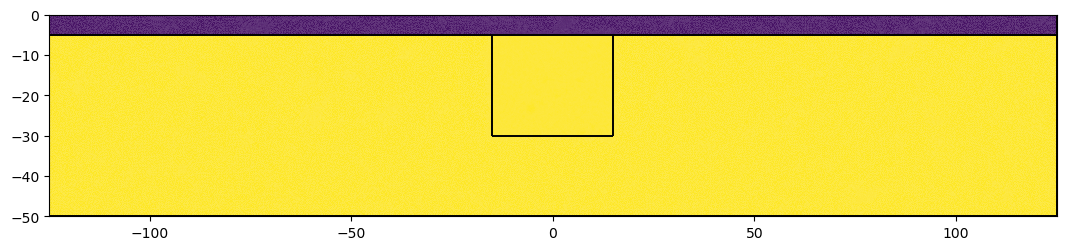

/Users/glennthompson/miniconda3/envs/pg/lib/python3.12/site-packages/pygimli/viewer/mpl/colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1300x400 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Axes: title={'center': 'Reference Vp model: with cave'}, xlabel='x [m]', ylabel='y [m]'>

<Figure size 640x480 with 0 Axes>

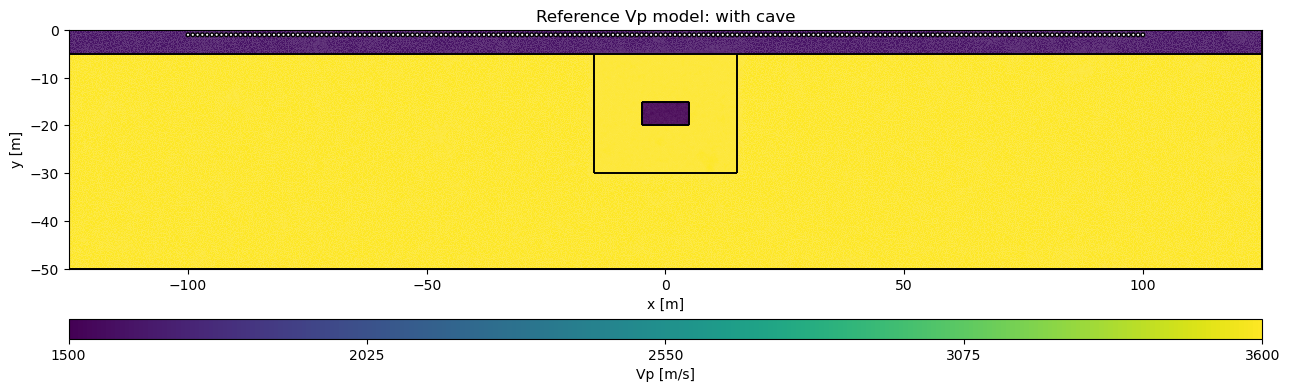

In [10]:
def draw_sensors(ax, scheme):
    pg.viewer.mpl.drawSensors(ax, scheme.sensors(), diam=0.75, facecolor="white", edgecolor="black")

def plot_cell_model(mesh, values, scheme=None, title="", label="", cmin=None, cmax=None):
    fig, ax = plt.subplots(figsize=(13, 4))
    ax, cb = pg.show(mesh, values, ax=ax, colorBar=True, label=label, logScale=False, cMin=cmin, cMax=cmax)
    if scheme is not None: draw_sensors(ax, scheme)
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    plt.tight_layout(); return ax

vp_min = min(model_no_cave["vp"].min(), model_with_cave["vp"].min())
vp_max = max(model_no_cave["vp"].max(), model_with_cave["vp"].max())
plot_cell_model(mesh_no_cave, model_no_cave["vp"], scheme=scheme, title="Reference Vp model: without cave", label="Vp [m/s]", cmin=vp_min, cmax=vp_max)
plot_cell_model(mesh_with_cave, model_with_cave["vp"], scheme=scheme, title="Reference Vp model: with cave", label="Vp [m/s]", cmin=vp_min, cmax=vp_max)

## 8. Forward model the full reference travel-time dataset

In [11]:
def set_positive_tt_errors(data, relative_error=0.03, absolute_error_s=0.001):
    t = np.asarray(data["t"], dtype=float)
    valid = np.isfinite(t) & (t > 0.0)
    err = np.maximum(relative_error * np.abs(t), absolute_error_s)
    err[~np.isfinite(err)] = absolute_error_s; err[err <= 0.0] = absolute_error_s
    data.set("err", err); data.set("valid", valid.astype(int)); data.removeInvalid()
    t = np.asarray(data["t"], dtype=float)
    err = np.maximum(relative_error * np.abs(t), absolute_error_s)
    err[~np.isfinite(err)] = absolute_error_s; err[err <= 0.0] = absolute_error_s
    data.set("err", err)
    return data

def copy_tt_data_with_positive_errors(data, relative_error=0.03, absolute_error_s=0.001):
    clean = pg.DataContainer(data)
    return set_positive_tt_errors(clean, relative_error=relative_error, absolute_error_s=absolute_error_s)

def simulate_first_arrivals(mesh, vp, scheme, pgcfg, add_noise=True):
    data = tt.simulate(slowness=1.0/vp, scheme=scheme, mesh=mesh,
                       noiseLevel=pgcfg["noise_level_relative"] if add_noise else 0.0,
                       noiseAbs=pgcfg["noise_abs_s"] if add_noise else 0.0,
                       seed=pgcfg["seed"], verbose=False)
    return set_positive_tt_errors(data, relative_error=pgcfg["error_relative"], absolute_error_s=pgcfg["error_abs_s"])

reference_dir = OUTPUT_DIR / "reference_model"
reference_dir.mkdir(parents=True, exist_ok=True)

data_no_cave = simulate_first_arrivals(mesh_no_cave, model_no_cave["vp"], scheme, pgcfg, add_noise=True)
data_with_cave = simulate_first_arrivals(mesh_with_cave, model_with_cave["vp"], scheme, pgcfg, add_noise=True)
print("No-cave data:", data_no_cave)
print("With-cave data:", data_with_cave)
print("Error range, no cave:", float(np.min(data_no_cave["err"])), float(np.max(data_no_cave["err"])))
print("Error range, with cave:", float(np.min(data_with_cave["err"])), float(np.max(data_with_cave["err"])))

04/05/26 - 18:06:50 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
04/05/26 - 18:07:33 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


No-cave data: Data: Sensors: 201 data: 30163, nonzero entries: ['err', 'g', 's', 't', 'valid']
With-cave data: Data: Sensors: 201 data: 30163, nonzero entries: ['err', 'g', 's', 't', 'valid']
Error range, no cave: 0.001 0.0016064484697825437
Error range, with cave: 0.001 0.0016058181152864288


## 9. Convert the full reference dataset to analysis tables

In [12]:
def scheme_dataframe(data):
    s = np.asarray(data["s"], dtype=int); g = np.asarray(data["g"], dtype=int); t = np.asarray(data["t"], dtype=float)
    sensors = data.sensors()
    sx = np.array([sensors[i].x() for i in s], dtype=float); sy = np.array([sensors[i].y() for i in s], dtype=float)
    gx = np.array([sensors[i].x() for i in g], dtype=float); gy = np.array([sensors[i].y() for i in g], dtype=float)
    df = pd.DataFrame({"s": s, "g": g, "source_x_m": sx, "source_y_m": sy,
                       "receiver_x_m": gx, "receiver_y_m": gy,
                       "offset_m": np.sqrt((gx-sx)**2 + (gy-sy)**2),
                       "midpoint_x_m": 0.5*(sx+gx), "t_s": t})
    try:
        if "err" in data.tokenList(): df["err_s"] = np.asarray(data["err"], dtype=float)
    except Exception: pass
    return df

df0 = scheme_dataframe(data_no_cave).rename(columns={"t_s": "t_no_cave_s"})
df1 = scheme_dataframe(data_with_cave).rename(columns={"t_s": "t_with_cave_s"})
df_reference = df0[["s", "g", "source_x_m", "source_y_m", "receiver_x_m", "receiver_y_m", "offset_m", "midpoint_x_m", "t_no_cave_s"]].merge(
    df1[["s", "g", "t_with_cave_s"]], on=["s", "g"], how="inner")
df_reference["dt_s"] = df_reference["t_with_cave_s"] - df_reference["t_no_cave_s"]
df_reference["dt_ms"] = 1000.0 * df_reference["dt_s"]
df_reference["abs_dt_ms"] = np.abs(df_reference["dt_ms"])
df_reference["percent_change"] = 100.0 * df_reference["dt_s"] / df_reference["t_no_cave_s"]
df_reference["source_x_round_m"] = df_reference["source_x_m"].round(6)
df_reference["receiver_x_round_m"] = df_reference["receiver_x_m"].round(6)
reference_csv = reference_dir / "reference_full_with_cave_minus_without_cave_traveltimes.csv"
df_reference.to_csv(reference_csv, index=False)
receivers.to_csv(reference_dir / "reference_receivers.csv", index=False)
shots.to_csv(reference_dir / "reference_shots.csv", index=False)
print(f"Wrote {reference_csv}")
print(df_reference["dt_ms"].describe())
display(df_reference.head())

Wrote karst_reference_oversampled_output/pygimli_reference_model/reference_model/reference_full_with_cave_minus_without_cave_traveltimes.csv
count    30160.000000
mean         0.002864
std          0.085968
min         -0.336814
25%         -0.053092
50%          0.003272
75%          0.057601
max          0.326091
Name: dt_ms, dtype: float64


,s,g,source_x_m,source_y_m,receiver_x_m,receiver_y_m,offset_m,midpoint_x_m,t_no_cave_s,t_with_cave_s,dt_s,dt_ms,abs_dt_ms,percent_change,source_x_round_m,receiver_x_round_m
0,0,25,-100.0,-1.0,-75.0,-1.0,25.0,-87.5,0.011395,0.011395,2.794680e-08,0.000028,0.000028,0.000245,-100.0,-75.0
1,0,26,-100.0,-1.0,-74.0,-1.0,26.0,-87.0,0.011865,0.011865,1.396007e-07,0.000140,0.000140,0.001177,-100.0,-74.0
2,0,27,-100.0,-1.0,-73.0,-1.0,27.0,-86.5,0.012416,0.012417,7.245391e-07,0.000725,0.000725,0.005835,-100.0,-73.0
3,0,28,-100.0,-1.0,-72.0,-1.0,28.0,-86.0,0.012606,0.012610,3.646166e-06,0.003646,0.003646,0.028924,-100.0,-72.0
4,0,29,-100.0,-1.0,-71.0,-1.0,29.0,-85.5,0.012559,0.012442,-1.163975e-04,-0.116397,0.116397,-0.926820,-100.0,-71.0


## 10. First-pass cave detectability diagnostics

In [13]:
def summarize_detectability(df, label="dataset"):
    return {"label": label, "n_traveltimes": len(df),
            "mean_abs_dt_ms": float(df["abs_dt_ms"].mean()),
            "median_abs_dt_ms": float(df["abs_dt_ms"].median()),
            "p90_abs_dt_ms": float(df["abs_dt_ms"].quantile(0.90)),
            "p95_abs_dt_ms": float(df["abs_dt_ms"].quantile(0.95)),
            "p99_abs_dt_ms": float(df["abs_dt_ms"].quantile(0.99)),
            "max_abs_dt_ms": float(df["abs_dt_ms"].max()),
            "mean_percent_change": float(df["percent_change"].mean()),
            "p95_abs_percent_change": float(df["percent_change"].abs().quantile(0.95))}
summary_reference = summarize_detectability(df_reference, "full_reference")
summary_reference

{'label': 'full_reference',
 'n_traveltimes': 30160,
 'mean_abs_dt_ms': 0.06751175678800615,
 'median_abs_dt_ms': 0.05526168804596658,
 'p90_abs_dt_ms': 0.14321145687877235,
 'p95_abs_dt_ms': 0.17134918368453944,
 'p99_abs_dt_ms': 0.22803640740578598,
 'max_abs_dt_ms': 0.33681433362791124,
 'mean_percent_change': 0.046736212152784076,
 'p95_abs_percent_change': 1.947568372035057}

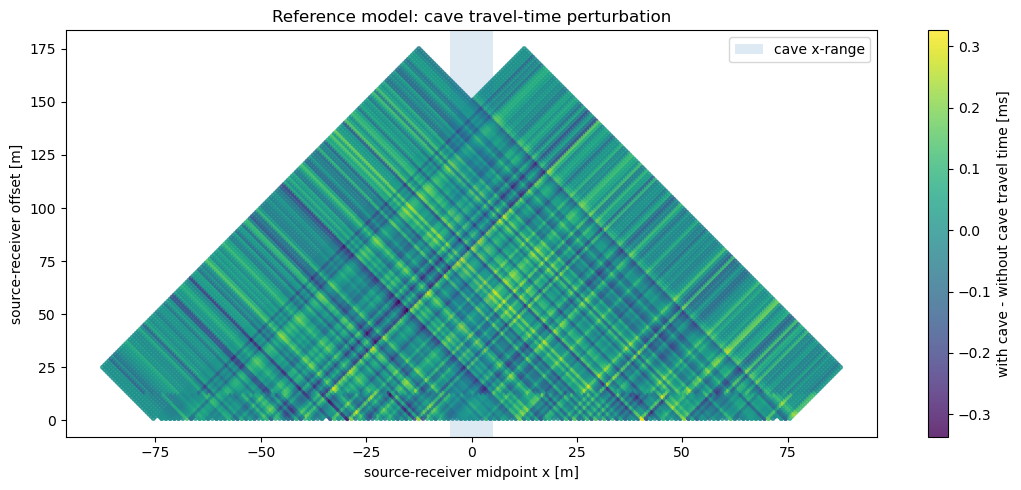

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
sc = ax.scatter(df_reference["midpoint_x_m"], df_reference["offset_m"], c=df_reference["dt_ms"], s=8, alpha=0.8)
cb = plt.colorbar(sc, ax=ax); cb.set_label("with cave - without cave travel time [ms]")
cave = cfg["cave"]; ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.15, label="cave x-range")
ax.set_xlabel("source-receiver midpoint x [m]"); ax.set_ylabel("source-receiver offset [m]")
ax.set_title("Reference model: cave travel-time perturbation"); ax.legend(); plt.tight_layout()

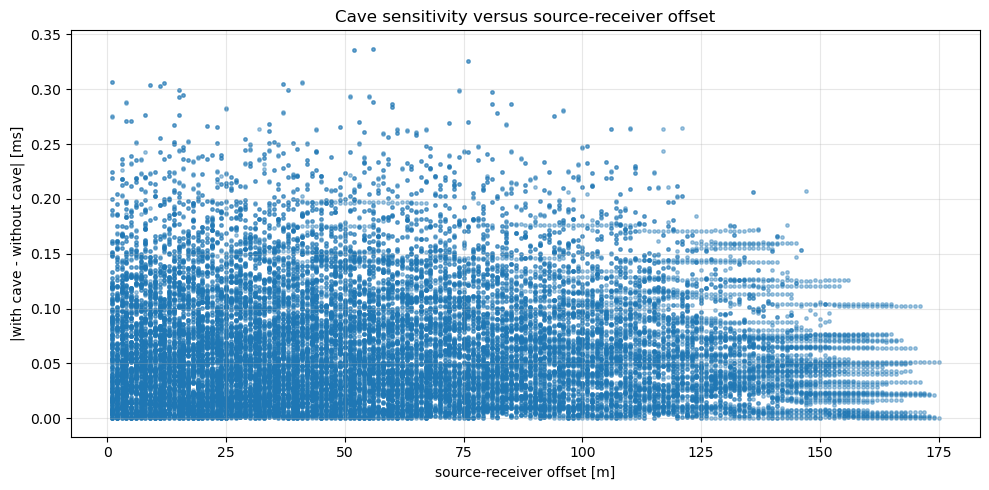

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_reference["offset_m"], df_reference["abs_dt_ms"], s=6, alpha=0.4)
ax.set_xlabel("source-receiver offset [m]"); ax.set_ylabel("|with cave - without cave| [ms]")
ax.set_title("Cave sensitivity versus source-receiver offset"); ax.grid(True, alpha=0.3); plt.tight_layout()

,offset_bin_m,n,mean_abs_dt_ms,p95_abs_dt_ms,max_abs_dt_ms
0,"(-0.001, 10.0]",2980,0.065939,0.171262,0.306970
1,"(10.0, 20.0]",3020,0.068368,0.175445,0.305899
2,"(20.0, 30.0]",2990,0.067819,0.174618,0.282573
3,"(30.0, 40.0]",2810,0.068137,0.174644,0.304836
4,"(40.0, 50.0]",2610,0.070704,0.175099,0.306139
5,"(50.0, 60.0]",2410,0.070977,0.183066,0.336814
6,"(60.0, 70.0]",2210,0.070873,0.180825,0.263482
7,"(70.0, 80.0]",2010,0.071772,0.177208,0.326091
8,"(80.0, 90.0]",1810,0.068297,0.169696,0.297741
9,"(90.0, 100.0]",1610,0.070068,0.172320,0.280975


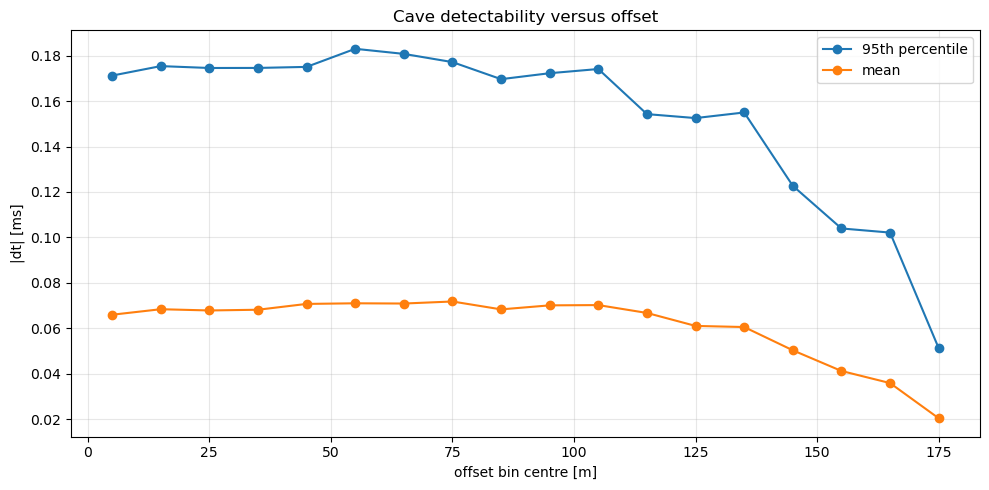

In [16]:
bins = np.arange(0, df_reference["offset_m"].max() + 10, 10)
df_reference["offset_bin_m"] = pd.cut(df_reference["offset_m"], bins=bins, include_lowest=True)
df_by_offset = df_reference.groupby("offset_bin_m", observed=True).agg(
    n=("abs_dt_ms", "size"), mean_abs_dt_ms=("abs_dt_ms", "mean"),
    p95_abs_dt_ms=("abs_dt_ms", lambda x: np.percentile(x, 95)), max_abs_dt_ms=("abs_dt_ms", "max")).reset_index()
display(df_by_offset)
fig, ax = plt.subplots(figsize=(10, 5))
x = [interval.mid for interval in df_by_offset["offset_bin_m"]]
ax.plot(x, df_by_offset["p95_abs_dt_ms"], marker="o", label="95th percentile")
ax.plot(x, df_by_offset["mean_abs_dt_ms"], marker="o", label="mean")
ax.set_xlabel("offset bin centre [m]"); ax.set_ylabel("|dt| [ms]")
ax.set_title("Cave detectability versus offset"); ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()

## 11. Background-model idea: fit away from the cave first

A defensible field workflow is to estimate the background model before looking for the cave.
For this synthetic notebook, the true background is known from the YAML. In the field, use far-field midpoints to estimate a smooth/1-D background, then map coherent residuals near the suspected cave.

In [17]:
def split_near_far_cave(df, cave_halfwidth_m=5.0, buffer_m=15.0):
    cave_center = 0.5 * (cfg["cave"]["x_min_m"] + cfg["cave"]["x_max_m"])
    near = df[np.abs(df["midpoint_x_m"] - cave_center) <= (cave_halfwidth_m + buffer_m)].copy()
    far = df[np.abs(df["midpoint_x_m"] - cave_center) > (cave_halfwidth_m + buffer_m)].copy()
    return near, far
near_cave, far_cave = split_near_far_cave(df_reference, cave_halfwidth_m=5.0, buffer_m=15.0)
pd.DataFrame([summarize_detectability(near_cave, "near_cave_midpoints"), summarize_detectability(far_cave, "far_from_cave_midpoints")])

,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change
0,near_cave_midpoints,11940,0.073536,0.062136,0.152825,0.183575,0.237877,0.336814,0.056852,1.540278
1,far_from_cave_midpoints,18220,0.063564,0.051613,0.136230,0.160895,0.217977,0.306970,0.040107,2.250660


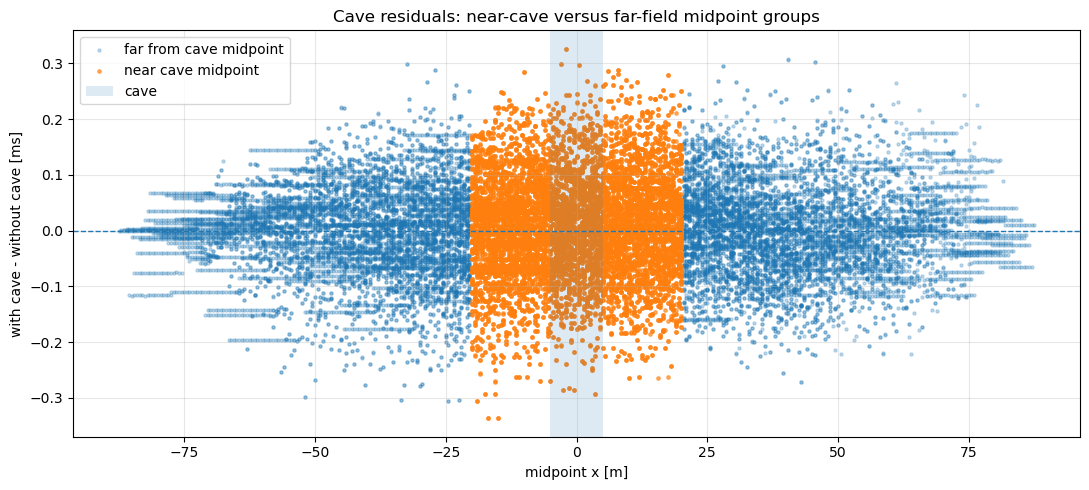

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(far_cave["midpoint_x_m"], far_cave["dt_ms"], s=5, alpha=0.25, label="far from cave midpoint")
ax.scatter(near_cave["midpoint_x_m"], near_cave["dt_ms"], s=6, alpha=0.6, label="near cave midpoint")
cave = cfg["cave"]; ax.axvspan(cave["x_min_m"], cave["x_max_m"], alpha=0.15, label="cave")
ax.axhline(0, linestyle="--", linewidth=1); ax.set_xlabel("midpoint x [m]"); ax.set_ylabel("with cave - without cave [ms]")
ax.set_title("Cave residuals: near-cave versus far-field midpoint groups"); ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()

## 12. Decimate shots and receivers from the full reference table

In [19]:
def subset_reference_table(df, *, receiver_spacing_m=1, shot_spacing_m=1, receiver_halfwidth_m=75, shot_halfwidth_m=100):
    sx = df["source_x_round_m"]; gx = df["receiver_x_round_m"]
    mask = ((sx.abs() <= shot_halfwidth_m) & (gx.abs() <= receiver_halfwidth_m)
            & np.isclose(np.mod(sx + 1000.0, shot_spacing_m), 0.0)
            & np.isclose(np.mod(gx + 1000.0, receiver_spacing_m), 0.0))
    return df.loc[mask].copy()

df_nodal_like = subset_reference_table(df_reference, receiver_spacing_m=4, shot_spacing_m=1, receiver_halfwidth_m=70, shot_halfwidth_m=100)
df_sparse_shots = subset_reference_table(df_reference, receiver_spacing_m=1, shot_spacing_m=5, receiver_halfwidth_m=75, shot_halfwidth_m=100)
pd.DataFrame([summarize_detectability(df_reference, "full 1m shots + 1m receivers"),
              summarize_detectability(df_nodal_like, "4m receiver spacing, all shots"),
              summarize_detectability(df_sparse_shots, "1m receivers, 5m shot spacing")])

,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change
0,full 1m shots + 1m receivers,30160,0.067512,0.055262,0.143211,0.171349,0.228036,0.336814,0.046736,1.947568
1,"4m receiver spacing, all shots",6989,0.074900,0.062209,0.154110,0.181781,0.239303,0.326091,0.082300,2.092166
2,"1m receivers, 5m shot spacing",6150,0.070990,0.057853,0.150080,0.180973,0.239560,0.336462,0.017535,2.107634


In [20]:
decim_cfg = pgcfg["decimation_experiments"]
receiver_spacings = decim_cfg.get("receiver_spacings_m", [1,2,4,5,10])
shot_spacings = decim_cfg.get("shot_spacings_m", [1,2,4,5,10])
receiver_halfwidths = decim_cfg.get("receiver_halfwidths_m", [25,35,50,75])
shot_halfwidths = decim_cfg.get("shot_halfwidths_m", [40,60,80,100])
rows=[]
for rspace in receiver_spacings:
    for sspace in shot_spacings:
        for rhw in receiver_halfwidths:
            for shw in shot_halfwidths:
                sub = subset_reference_table(df_reference, receiver_spacing_m=rspace, shot_spacing_m=sspace, receiver_halfwidth_m=rhw, shot_halfwidth_m=shw)
                if len(sub)==0: continue
                row = summarize_detectability(sub, label=f"r{rspace:g}_s{sspace:g}_rhw{rhw:g}_shw{shw:g}")
                row.update({"receiver_spacing_m":rspace,"shot_spacing_m":sspace,"receiver_halfwidth_m":rhw,"shot_halfwidth_m":shw,
                            "receiver_count_approx": int(2*rhw/rspace+1), "shot_count_approx": int(2*shw/sspace+1)})
                rows.append(row)
df_decimation = pd.DataFrame(rows)
decimation_csv = reference_dir / "reference_decimation_detectability_summary.csv"
df_decimation.to_csv(decimation_csv, index=False)
print(f"Wrote {decimation_csv}")
display(df_decimation.sort_values("p95_abs_dt_ms", ascending=False).head(20))

Wrote karst_reference_oversampled_output/pygimli_reference_model/reference_model/reference_decimation_detectability_summary.csv


,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change,receiver_spacing_m,shot_spacing_m,receiver_halfwidth_m,shot_halfwidth_m,receiver_count_approx,shot_count_approx
464,r10_s10_rhw25_shw40,40,0.099634,0.122656,0.174414,0.245563,0.268803,0.283619,0.348075,2.102386,10,10,25,40,6,9
432,r10_s4_rhw25_shw40,102,0.102296,0.090868,0.197524,0.245464,0.288104,0.294682,0.356921,3.357562,10,4,25,40,6,21
433,r10_s4_rhw25_shw60,152,0.099102,0.084243,0.197524,0.243116,0.285839,0.294682,0.303759,3.089188,10,4,25,60,6,31
312,r4_s10_rhw50_shw40,219,0.106952,0.096062,0.213950,0.242802,0.287700,0.326091,0.249334,3.949182,4,10,50,40,26,9
392,r5_s10_rhw50_shw40,180,0.096921,0.091417,0.198436,0.239400,0.288194,0.299447,0.110778,2.835744,5,10,50,40,21,9
304,r4_s10_rhw25_shw40,113,0.099505,0.087157,0.197154,0.238967,0.249782,0.283619,0.301780,3.246646,4,10,25,40,13,9
224,r3_s10_rhw25_shw40,151,0.096703,0.079123,0.198514,0.236000,0.267232,0.299447,0.289470,3.173788,3,10,25,40,17,9
232,r3_s10_rhw50_shw40,303,0.096483,0.084559,0.195371,0.235446,0.283789,0.306567,0.861053,4.053688,3,10,50,40,34,9
316,r4_s10_rhw75_shw40,327,0.099369,0.084206,0.204172,0.234617,0.283747,0.326091,0.215416,3.069389,4,10,75,40,38,9
440,r10_s4_rhw50_shw40,226,0.099932,0.089006,0.201935,0.234245,0.287060,0.325621,0.258787,3.323028,10,4,50,40,11,21


## 13. How much do we lose by removing geophones?

,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change,receiver_spacing_m,receiver_halfwidth_m,n_receivers_approx
22,"receiver spacing 10 m, halfwidth 50 m",2194,0.079149,0.064518,0.164154,0.196456,0.260923,0.325621,0.153300,2.525899,10,50,11
18,"receiver spacing 5 m, halfwidth 50 m",4192,0.077193,0.062544,0.160575,0.193941,0.250797,0.336814,0.110213,2.434152,5,50,21
20,"receiver spacing 10 m, halfwidth 25 m",997,0.081647,0.068517,0.162375,0.193754,0.249619,0.294682,0.258506,2.178519,10,25,6
14,"receiver spacing 4 m, halfwidth 50 m",4990,0.079221,0.066722,0.161733,0.189656,0.244629,0.326091,0.117727,2.305715,4,50,26
8,"receiver spacing 3 m, halfwidth 25 m",3397,0.080029,0.068695,0.160663,0.188135,0.242723,0.336462,0.069687,2.293714,3,25,17
23,"receiver spacing 10 m, halfwidth 75 m",2994,0.073454,0.059948,0.155018,0.185272,0.244587,0.325621,0.123889,2.412818,10,75,16
10,"receiver spacing 3 m, halfwidth 50 m",6792,0.073816,0.061284,0.151483,0.181627,0.236976,0.336462,0.068574,2.221674,3,50,34
19,"receiver spacing 5 m, halfwidth 75 m",6191,0.072872,0.059583,0.153236,0.181540,0.242390,0.336814,0.059506,2.146422,5,75,31
15,"receiver spacing 4 m, halfwidth 75 m",7387,0.073217,0.059718,0.151341,0.180633,0.237991,0.326091,0.082448,2.054198,4,75,38
16,"receiver spacing 5 m, halfwidth 25 m",2196,0.073929,0.059381,0.148632,0.180442,0.240056,0.305704,0.198022,2.083721,5,25,11


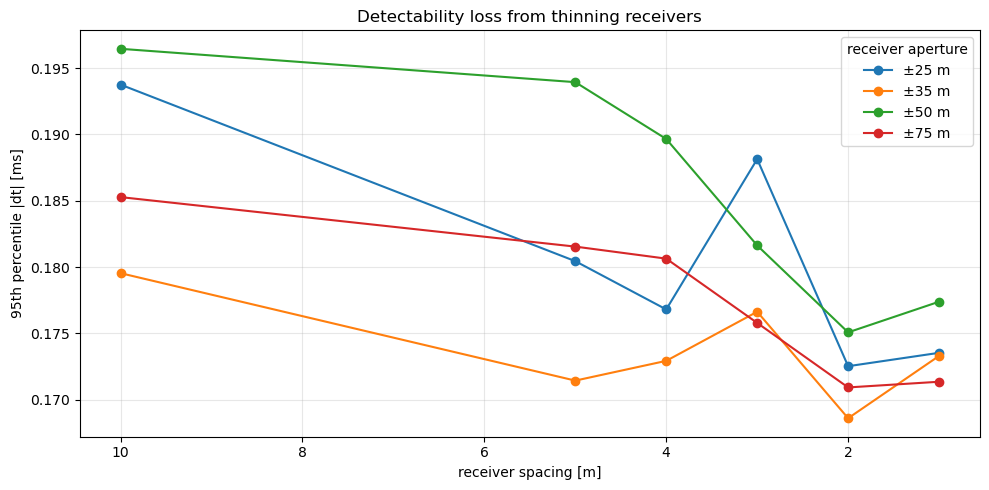

In [21]:
rows=[]
for rspace in receiver_spacings:
    for rhw in receiver_halfwidths:
        sub = subset_reference_table(df_reference, receiver_spacing_m=rspace, shot_spacing_m=1, receiver_halfwidth_m=rhw, shot_halfwidth_m=100)
        row = summarize_detectability(sub, f"receiver spacing {rspace} m, halfwidth {rhw} m")
        row.update({"receiver_spacing_m": rspace, "receiver_halfwidth_m": rhw, "n_receivers_approx": int(2*rhw/rspace+1)})
        rows.append(row)
df_receiver_loss = pd.DataFrame(rows)
display(df_receiver_loss.sort_values("p95_abs_dt_ms", ascending=False))
fig, ax = plt.subplots(figsize=(10,5))
for rhw, sub in df_receiver_loss.groupby("receiver_halfwidth_m"):
    ax.plot(sub["receiver_spacing_m"], sub["p95_abs_dt_ms"], marker="o", label=f"±{rhw:g} m")
ax.set_xlabel("receiver spacing [m]"); ax.set_ylabel("95th percentile |dt| [ms]"); ax.set_title("Detectability loss from thinning receivers")
ax.invert_xaxis(); ax.legend(title="receiver aperture"); ax.grid(True, alpha=0.3); plt.tight_layout()

## 14. How much do we lose by removing shots?

,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change,shot_spacing_m,shot_halfwidth_m,n_shots_approx
16,"shot spacing 10 m, halfwidth 40 m",1347,0.090902,0.077677,0.181773,0.213439,0.282096,0.326091,0.255373,3.239390,10,40,9
8,"shot spacing 4 m, halfwidth 40 m",3146,0.084698,0.074214,0.171294,0.202632,0.260708,0.326091,0.290930,2.773080,4,40,21
17,"shot spacing 10 m, halfwidth 60 m",1944,0.082361,0.068275,0.168336,0.199532,0.266185,0.326091,0.211398,3.024110,10,60,13
13,"shot spacing 5 m, halfwidth 60 m",3742,0.079330,0.066061,0.164675,0.197862,0.251599,0.336462,0.060836,2.910468,5,60,25
12,"shot spacing 5 m, halfwidth 40 m",2546,0.079748,0.065812,0.165812,0.197802,0.261360,0.326091,0.110167,2.984799,5,40,17
9,"shot spacing 4 m, halfwidth 60 m",4643,0.081948,0.070889,0.166046,0.197318,0.248124,0.326091,0.183090,2.664924,4,60,31
14,"shot spacing 5 m, halfwidth 80 m",4942,0.076183,0.063543,0.157278,0.190581,0.245258,0.336462,0.022542,2.664487,5,80,33
18,"shot spacing 10 m, halfwidth 80 m",2546,0.076509,0.062503,0.160482,0.190501,0.249981,0.326091,0.156573,2.793685,10,80,17
4,"shot spacing 2 m, halfwidth 40 m",6139,0.077884,0.066985,0.160100,0.189920,0.245603,0.326091,0.123351,2.775692,2,40,41
10,"shot spacing 4 m, halfwidth 80 m",6144,0.076807,0.064935,0.158786,0.189051,0.243413,0.326091,0.144793,2.342959,4,80,41


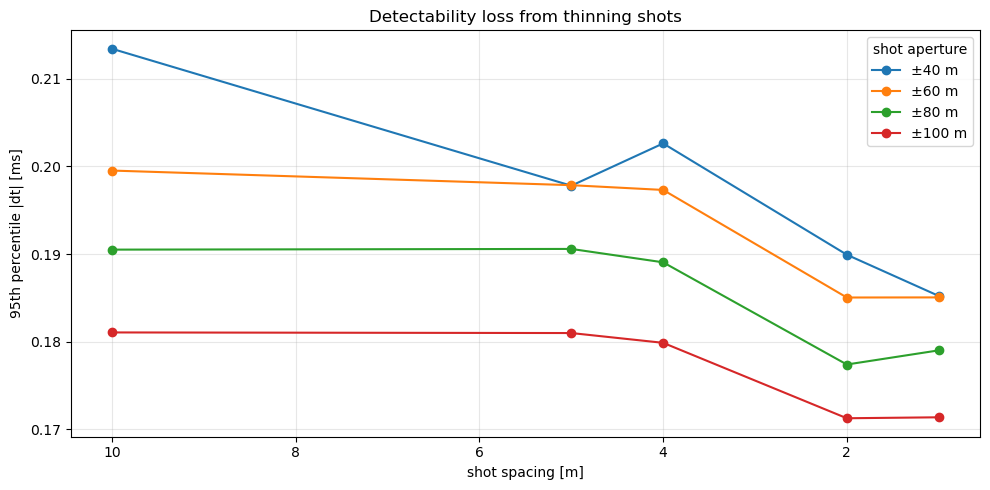

In [22]:
rows=[]
for sspace in shot_spacings:
    for shw in shot_halfwidths:
        sub = subset_reference_table(df_reference, receiver_spacing_m=1, shot_spacing_m=sspace, receiver_halfwidth_m=75, shot_halfwidth_m=shw)
        row = summarize_detectability(sub, f"shot spacing {sspace} m, halfwidth {shw} m")
        row.update({"shot_spacing_m": sspace, "shot_halfwidth_m": shw, "n_shots_approx": int(2*shw/sspace+1)})
        rows.append(row)
df_shot_loss = pd.DataFrame(rows)
display(df_shot_loss.sort_values("p95_abs_dt_ms", ascending=False))
fig, ax = plt.subplots(figsize=(10,5))
for shw, sub in df_shot_loss.groupby("shot_halfwidth_m"):
    ax.plot(sub["shot_spacing_m"], sub["p95_abs_dt_ms"], marker="o", label=f"±{shw:g} m")
ax.set_xlabel("shot spacing [m]"); ax.set_ylabel("95th percentile |dt| [ms]"); ax.set_title("Detectability loss from thinning shots")
ax.invert_xaxis(); ax.legend(title="shot aperture"); ax.grid(True, alpha=0.3); plt.tight_layout()

## 15. Is aperture more important than spacing?

,label,n_traveltimes,mean_abs_dt_ms,median_abs_dt_ms,p90_abs_dt_ms,p95_abs_dt_ms,p99_abs_dt_ms,max_abs_dt_ms,mean_percent_change,p95_abs_percent_change,receiver_halfwidth_m,shot_halfwidth_m,n_receivers_approx,n_shots_approx
8,"rhw 50, shw 40",856,0.085317,0.071506,0.176181,0.207135,0.265312,0.326091,0.044335,4.116350,50,40,51,17
9,"rhw 50, shw 60",1261,0.083624,0.070532,0.171237,0.203919,0.263194,0.326091,-0.017192,3.486849,50,60,51,25
12,"rhw 75, shw 40",1264,0.081220,0.067833,0.168641,0.200471,0.261186,0.326091,0.064710,3.029023,75,40,76,17
4,"rhw 35, shw 40",586,0.081140,0.069125,0.167386,0.198532,0.246742,0.299451,0.005105,4.324510,35,40,36,17
5,"rhw 35, shw 60",866,0.080763,0.069125,0.165920,0.198289,0.252064,0.306139,-0.044396,3.139645,35,60,36,25
1,"rhw 25, shw 60",619,0.081696,0.070231,0.166748,0.197859,0.245618,0.306139,0.015928,3.032642,25,60,26,25
13,"rhw 75, shw 60",1859,0.079812,0.067485,0.164662,0.197820,0.252407,0.326091,0.036509,2.972739,75,60,76,25
0,"rhw 25, shw 40",419,0.081371,0.070009,0.166748,0.197576,0.245254,0.283619,0.074669,4.154151,25,40,26,17
10,"rhw 50, shw 80",1669,0.080802,0.069471,0.164625,0.197379,0.251917,0.326091,-0.020507,2.902784,50,80,51,33
2,"rhw 25, shw 80",819,0.079738,0.069036,0.160187,0.194090,0.243651,0.306139,-0.003392,2.690205,25,80,26,33


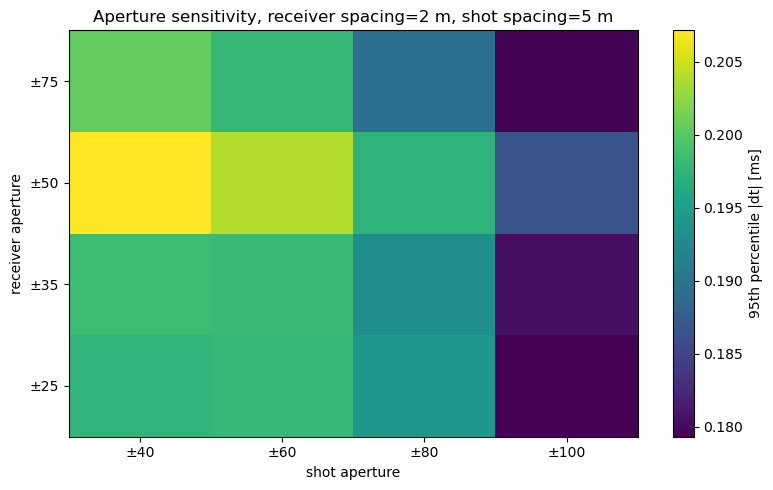

In [23]:
receiver_spacing_practical = 2; shot_spacing_practical = 5
rows=[]
for rhw in receiver_halfwidths:
    for shw in shot_halfwidths:
        sub = subset_reference_table(df_reference, receiver_spacing_m=receiver_spacing_practical, shot_spacing_m=shot_spacing_practical, receiver_halfwidth_m=rhw, shot_halfwidth_m=shw)
        row = summarize_detectability(sub, f"rhw {rhw}, shw {shw}")
        row.update({"receiver_halfwidth_m": rhw, "shot_halfwidth_m": shw, "n_receivers_approx": int(2*rhw/receiver_spacing_practical+1), "n_shots_approx": int(2*shw/shot_spacing_practical+1)})
        rows.append(row)
df_aperture = pd.DataFrame(rows)
display(df_aperture.sort_values("p95_abs_dt_ms", ascending=False))
pivot = df_aperture.pivot(index="receiver_halfwidth_m", columns="shot_halfwidth_m", values="p95_abs_dt_ms")
fig, ax = plt.subplots(figsize=(8,5)); im=ax.imshow(pivot.values, origin="lower", aspect="auto"); cb=plt.colorbar(im, ax=ax); cb.set_label("95th percentile |dt| [ms]")
ax.set_xticks(np.arange(len(pivot.columns))); ax.set_xticklabels([f"±{c:g}" for c in pivot.columns])
ax.set_yticks(np.arange(len(pivot.index))); ax.set_yticklabels([f"±{r:g}" for r in pivot.index])
ax.set_xlabel("shot aperture"); ax.set_ylabel("receiver aperture"); ax.set_title(f"Aperture sensitivity, receiver spacing={receiver_spacing_practical} m, shot spacing={shot_spacing_practical} m")
plt.tight_layout()

## 16. Build PyGIMLi data containers from decimated tables

In [24]:
def data_container_from_subset(df_subset, t_column="t_with_cave_s", err_relative=0.03, err_abs_s=0.001):
    data = pg.DataContainer(); data.registerSensorIndex("s"); data.registerSensorIndex("g")
    sensor_lookup={}
    def add_sensor(x,y):
        key=(round(float(x),6), round(float(y),6))
        if key not in sensor_lookup: sensor_lookup[key] = data.createSensor([float(x), float(y), 0.0])
        return int(sensor_lookup[key])
    s_ids=[]; g_ids=[]; times=[]
    for _, row in df_subset.iterrows():
        sid=add_sensor(row["source_x_m"], row["source_y_m"]); gid=add_sensor(row["receiver_x_m"], row["receiver_y_m"])
        if sid==gid: continue
        s_ids.append(sid); g_ids.append(gid); times.append(float(row[t_column]))
    data.resize(len(times)); data.set("s", s_ids); data.set("g", g_ids); data.set("t", times); data.set("valid", np.ones(len(times)))
    t=np.asarray(times,dtype=float); data.set("err", np.maximum(err_relative*np.abs(t), err_abs_s))
    return data

def invert_travel_times(data, title, lam=20.0, para_max_cell_size_m2=10.0, max_iter=8, sec_nodes=2):
    clean_data = copy_tt_data_with_positive_errors(data, relative_error=pgcfg["error_relative"], absolute_error_s=pgcfg["error_abs_s"])
    err=np.asarray(clean_data["err"], dtype=float)
    print(title); print(f"  data count: {clean_data.size()}"); print(f"  error range: {err.min():.6g} to {err.max():.6g} s")
    mgr=tt.TravelTimeManager()
    velocity = mgr.invert(data=clean_data, err=err, secNodes=sec_nodes, paraMaxCellSize=para_max_cell_size_m2, maxIter=max_iter, lam=lam, verbose=True)
    ax,_ = mgr.showResult(logScale=False); ax.set_title(title); plt.tight_layout()
    mgr.showFit(firstPicks=True); plt.title(f"Fit: {title}"); plt.tight_layout()
    return {"manager": mgr, "velocity": velocity, "data": clean_data}

## 17. Optional selected inversions

In [25]:
RUN_SELECTED_INVERSIONS = False
selected_designs = {
    "full_reference": dict(receiver_spacing_m=1, shot_spacing_m=1, receiver_halfwidth_m=75, shot_halfwidth_m=100),
    "nodal_like_4m_receivers": dict(receiver_spacing_m=4, shot_spacing_m=1, receiver_halfwidth_m=70, shot_halfwidth_m=100),
    "practical_2m_rec_5m_shots": dict(receiver_spacing_m=2, shot_spacing_m=5, receiver_halfwidth_m=75, shot_halfwidth_m=100),
    "short_aperture": dict(receiver_spacing_m=2, shot_spacing_m=5, receiver_halfwidth_m=35, shot_halfwidth_m=60),
}
inversion_results={}
if RUN_SELECTED_INVERSIONS:
    for name, params in selected_designs.items():
        print("="*80); print(name, params); print("="*80)
        sub = subset_reference_table(df_reference, **params)
        data_sub = data_container_from_subset(sub, t_column="t_with_cave_s", err_relative=pgcfg["error_relative"], err_abs_s=pgcfg["error_abs_s"])
        inversion_results[name] = invert_travel_times(data_sub, title=f"Inversion: {name}", lam=20.0, para_max_cell_size_m2=10.0, max_iter=8, sec_nodes=2)
else:
    print("Selected inversions are disabled. Set RUN_SELECTED_INVERSIONS = True to run them.")

Selected inversions are disabled. Set RUN_SELECTED_INVERSIONS = True to run them.


## 18. Interpretation checklist

Use the outputs above as follows:

### Cave detectability from residuals

The strongest first-pass metric is `p95_abs_dt_ms`. This tells us whether the cave produces travel-time perturbations larger than realistic picking/model errors.

### Shots versus geophones

- If thinning shots causes little degradation, you can reduce source effort.
- If thinning receivers causes little degradation, sparse nodal surveys may be enough.
- If aperture dominates spacing, keep the line long even if you must use fewer stations.

### Background model first?

Yes, for a real survey:

1. Use far-field midpoints and long offsets to estimate the background 2-layer model.
2. Use the background model to predict travel times.
3. Map residuals over midpoint/offset space.
4. Then run 2-D inversion only after confirming coherent residuals near the target.

### What would count as successful cave resolution?

1. Synthetic with-cave residuals are significantly above assumed pick error.
2. Residuals localize around the cave in midpoint/offset space.
3. Decimated practical geometry preserves the residual signature.
4. Inversion produces a repeatable low-velocity anomaly near the true cave.
5. Similar anomaly is absent in no-cave/control inversions.